<a href="https://colab.research.google.com/github/o-semenkova/ml_home_tasks/blob/main/Mid_term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в банку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Зчитуємо дані з Google Drive
raw_dataset = pd.read_csv("drive/MyDrive/colab_notebooks/machine-learning-by-hanna-pylieva/midterm/data/bank-additional-full.csv", sep=";")

In [14]:
# Огляд декількох записів з датафрейму
raw_dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [17]:
raw_dataset.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [18]:
raw_dataset.shape

(41188, 21)

**Датасет має 21 стовпець та 41 188 строк, а також бачимо, що пропущених значень немає**

In [19]:
raw_dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


**Аналіз описових статистик:**

**age** — середній вік клієнта ~40 років, розподіл досить типовий (std=10.4), діапазон від 17 до 98. Медіана (38) трохи нижче середнього — легка правостороння асиметрія, є старші клієнти, які "тягнуть" середнє вгору. В цілому нічого аномального.

**duration** — тривалість дзвінка, середня ~258 сек (~4.3 хв), але std майже дорівнює mean (259), що говорить про дуже широкий розкид. Є значення 0 (дзвінок не відбувся) і максимум 4918 сек (~82 хв). Розподіл явно правосторонній (медіана 180, набагато менше mean). Як зазначено в описі задачі — цю змінну не варто включати у фінальну модель, бо вона відома лише після дзвінка.

**campaign** — кількість контактів у поточній кампанії. Медіана = 2, mean = 2.57, але max = 56 — є клієнти, яким дзвонили дуже багато разів. Це потенційні outliers. 75-й перцентиль лише 3, тобто основна маса — 1–3 дзвінки, а хвіст дуже довгий.

**pdays** — дні від попереднього контакту. Медіана і 25-й перцентиль = 999, що означає, що більшість клієнтів не контактувались у попередній кампанії. Значення 999 — це фактично "не було контакту", а не реальна кількість днів. Цю змінну варто перетворити, наприклад, зробити бінарну ознаку "чи був попередній контакт" (pdays != 999).

**previous** — кількість контактів до поточної кампанії. Mean = 0.17, 75-й перцентиль = 0, max = 7. Тобто переважна більшість клієнтів раніше не контактувались (узгоджується з pdays). Дуже розріджена змінна.

**emp.var.rate** — темп зміни зайнятості. Діапазон від -3.4 до 1.4, медіана 1.1, тобто більшість спостережень припадає на період позитивної динаміки зайнятості. Це макроекономічний показник — однаковий для всіх клієнтів у конкретний період.

**cons.price.idx** — індекс споживчих цін. Дуже вузький діапазон (92.2–94.77), std = 0.58. Також макропоказник. Може бути корисний як індикатор економічного контексту кампанії.

**cons.conf.idx** — індекс довіри споживачів. Усі значення від'ємні (від -50.8 до -26.9), що типово для цього індексу. Середнє = -40.5. Теж макрозмінна.
euribor3m — ставка Euribor 3 місяці. Від 0.63 до 5.04, медіана 4.86 — тобто розподіл зміщений вліво, більшість спостережень при високій ставці, але є період низьких ставок. Сильно корелюватиме з іншими макрозмінними.

**nr.employed** — кількість працевлаштованих. Вузький діапазон (4963–5228), медіана 5191. Також макрозмінна, ймовірно високо корельована з emp.var.rate та euribor3m.

**Ключові висновки для подальшої роботи:**


*   Макрозмінні (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) будуть сильно корельовані між собою — варто це перевірити і, можливо, прибрати частину.
*   pdays потребує спеціальної обробки (999 — не число, а маркер відсутності контакту).
*   campaign має outliers у правому хвості.


In [21]:
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

nr.employed      -0.35
euribor3m        -0.31
emp.var.rate     -0.30
cons.price.idx   -0.14
cons.conf.idx     0.05
Name: y_num, dtype: float64


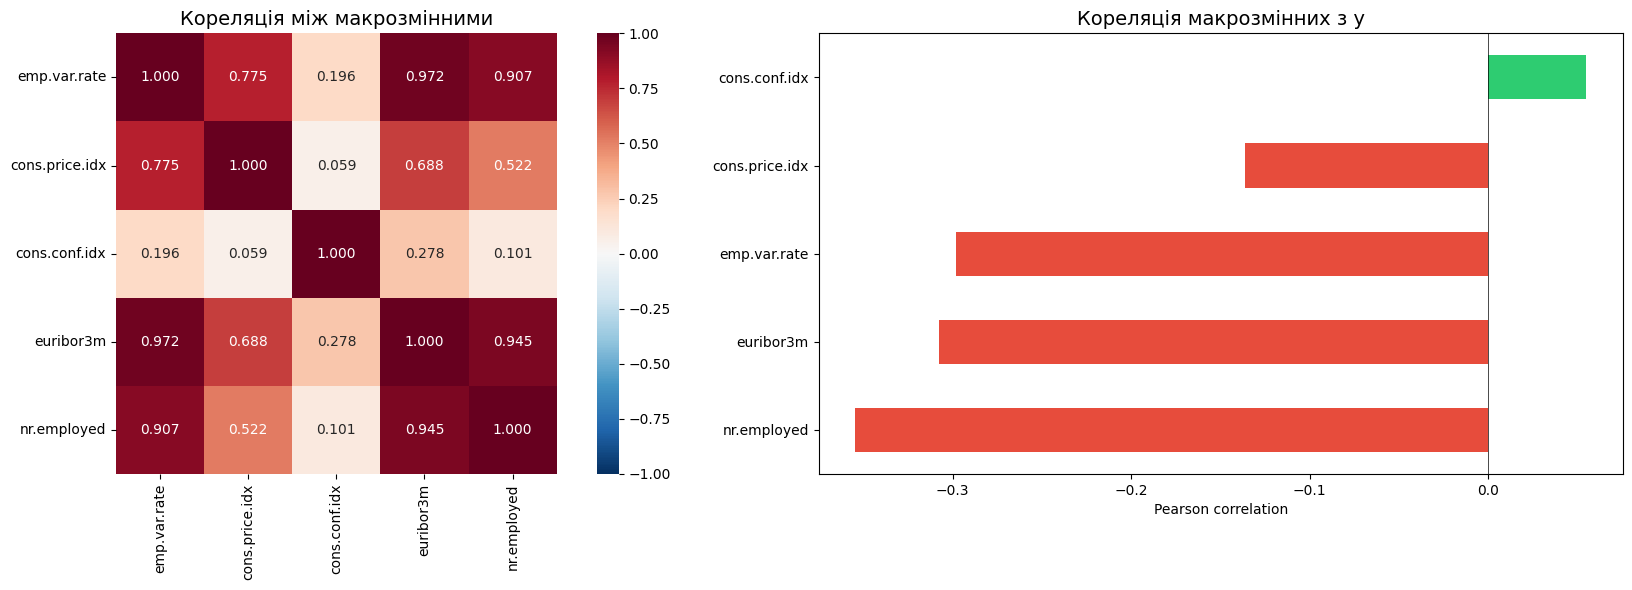

In [33]:
# КОРЕЛЯЦІЙНА МАТРИЦЯ (макрозмінні між собою) та КОРЕЛЯЦІЯ З ЦІЛЬОВОЮ ЗМІННОЮ y
corr_macro = raw_dataset[macro_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(corr_macro, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('Кореляція між макрозмінними', fontsize=14)
raw_dataset['y_num'] = (raw_dataset['y'] == 'yes').astype(int)
corr_with_y = raw_dataset[macro_cols + ['y_num']].corr()['y_num'].drop('y_num').sort_values()
print(corr_with_y.round(4))

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_y.values]
corr_with_y.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Кореляція макрозмінних з y', fontsize=14)
axes[1].set_xlabel('Pearson correlation')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('macro_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:

# VIF (Variance Inflation Factor)

print("VIF > 5  — помірна мультиколінеарність")
print("VIF > 10 — сильна мультиколінеарність\n")

X_macro = raw_dataset[macro_cols].dropna()
vif_data = pd.DataFrame({
    'Змінна': macro_cols,
    'VIF': [variance_inflation_factor(X_macro.values, i) for i in range(len(macro_cols))]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))


VIF > 5  — помірна мультиколінеарність
VIF > 10 — сильна мультиколінеарність

        Змінна      VIF
   nr.employed 25472.32
cons.price.idx 21362.91
     euribor3m   224.71
 cons.conf.idx   116.61
  emp.var.rate    28.70


In [41]:
# Ітеративне видалення за VIF (поріг = 10)

remaining = macro_cols.copy()
removed = []

while True:
    X_temp = raw_dataset[remaining].dropna()
    vifs = [variance_inflation_factor(X_temp.values, i) for i in range(len(remaining))]
    max_vif = max(vifs)
    max_idx = vifs.index(max_vif)

    if max_vif <= 10:
        break

    removed_var = remaining[max_idx]
    corr_y_val = abs(corr_with_y.get(removed_var, 0))
    print(f"Видаляємо: {removed_var:20s} (VIF={max_vif:.1f}, |corr з y|={corr_y_val:.4f})")
    removed.append(removed_var)
    remaining.remove(removed_var)

print(f"\nВидалені змінні:  {removed}")
print(f"Залишені змінні:  {remaining}")

print("\nФінальний VIF:")
raw_data_linear_models = raw_dataset[remaining].dropna()
for i, col in enumerate(remaining):
    vif = variance_inflation_factor(raw_data_linear_models.values, i)
    print(f"  {col:20s} VIF = {vif:.2f}")

Видаляємо: nr.employed          (VIF=25472.3, |corr з y|=0.3547)
Видаляємо: cons.price.idx       (VIF=243.3, |corr з y|=0.1362)
Видаляємо: euribor3m            (VIF=36.7, |corr з y|=0.3078)

Видалені змінні:  ['nr.employed', 'cons.price.idx', 'euribor3m']
Залишені змінні:  ['emp.var.rate', 'cons.conf.idx']

Фінальний VIF:
  emp.var.rate         VIF = 1.00
  cons.conf.idx        VIF = 1.00


Для лінійних моделей (Logistic Regression) краще залишити emp.var.rate + cons.conf.idx, тобто для них будемо використовувати датасет **raw_data_linear_models**.
А от для дерев і бустингу мультиколінеарність не є проблемою, тому там можна спокійно залишити всі п'ять — модель сама розбереться, тож тут будемо використовувати звичайний **raw_dataset**